# Type B — Funded-Continuation Recovery Hedge

**Hedge Type:** You hedge through the challenge, get funded, and **keep hedging at funded**. The funded-stage hedge is sized so that if the funded account eventually fails, the hedge side recovers the full historical cost stack.

**Goal:** Challenge costs become recoverable capital, not sunk costs.

## EV Formula

$$\text{EV}_B = \text{funded withdrawals} - \text{net funded hedge drag}$$

The challenge cost stack is no longer dead money — it is the insured base that the funded hedge is protecting.

## Key Question

> "If I keep hedging the funded account, can I treat challenge costs as recoverable capital instead of sunk capital?"

## Worked Example

| Metric | Value |
|--------|-------|
| Challenge fee | $500 |
| Challenge hedge losses | $800 |
| Cost stack at funding | $1,300 |
| Funded withdrawals before failure | $3,000 |
| Funded hedge drag | $700 |
| Recovery on failure (hedge wins) | ≈ $2,000 (the built-up stack) |
| **EV_B** | **$3,000 − $700 = $2,300** |

The failure event does not wipe out the historical stack — the hedge was carrying it.

---

**Reference:** [hedging-explained.md](../Product/hedging-explained.md) §5 Type B

## 0 — Setup & Imports

In [1]:
import sys, os, json, math, glob, importlib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

WS_ROOT = os.environ.get(
    "WORKSPACE_ROOT",
    r"C:\Users\sossi\Desktop\Business\Orchestrator Hedge Edge"
)
if WS_ROOT not in sys.path:
    sys.path.insert(0, WS_ROOT)

STRATEGY_ROOT = os.path.join(WS_ROOT, "Business", "STRATEGY")
DATA_DIR = os.path.join(STRATEGY_ROOT, "resources", "PropFirmData")

exec_path = os.path.join(STRATEGY_ROOT, "executions")
if exec_path not in sys.path:
    sys.path.insert(0, exec_path)

plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 120

# ── Tuneable assumptions ──
FUNDED_TARGET = 0.08     # 8% funded target (for challenge phase)
SPREAD_COST   = 0.0003   # 3 pips per side
RESIZES_PER_PHASE = 20

# ── Type B funded-phase assumptions ──
FUNDED_WITHDRAWAL_PCT = 0.04   # withdraw 4% of account per cycle
FUNDED_CYCLES = 6              # number of withdrawal cycles modelled
FUNDED_SURVIVAL_RATE = 0.80    # probability of surviving each cycle
FUNDED_HEDGE_DRAG_PCT = 0.015  # hedge drag per cycle as % of account

print("Type B notebook ready.")
print(f"Challenge: funded_target={FUNDED_TARGET*100:.0f}%, spread={SPREAD_COST}")
print(f"Funded: withdrawal={FUNDED_WITHDRAWAL_PCT*100:.1f}%/cycle, "
      f"survival={FUNDED_SURVIVAL_RATE*100:.0f}%/cycle, "
      f"drag={FUNDED_HEDGE_DRAG_PCT*100:.1f}%/cycle")

Type B notebook ready.
Challenge: funded_target=8%, spread=0.0003
Funded: withdrawal=4.0%/cycle, survival=80%/cycle, drag=1.5%/cycle


## 1 — Load Data & Classify Drawdown

In [2]:
json_files = glob.glob(os.path.join(DATA_DIR, "propmatch_challenges_*.json"))
if not json_files:
    raise FileNotFoundError("No scraped data.")

latest = max(json_files, key=os.path.getmtime)
print(f"Loading: {os.path.basename(latest)}")

with open(latest, 'r', encoding='utf-8') as f:
    raw = json.load(f)

challenges = raw.get("challenges", raw if isinstance(raw, list) else [])
print(f"Loaded {len(challenges)} challenges")

def classify_drawdown(dd_type_str):
    if not dd_type_str or dd_type_str == "-":
        return "static"
    if "trailing" in dd_type_str.lower():
        return "trailing"
    return "static"

Loading: propmatch_challenges_20260324_183523.json
Loaded 224 challenges


## 2 — Type B Model: Challenge Phase + Funded Continuation

### How Type B extends Type A

Type A stops at funding. Type B continues:

1. **Challenge phase** — identical to Type A. Hedge guarantees you pass, costs accumulate.
2. **Funded phase** — hedge continues. Each withdrawal cycle:
   - You withdraw profits from the funded account
   - The hedge absorbs drag (it loses when funded account profits)
   - The insured stack keeps growing by the drag amount
   - If the funded account eventually fails → hedge recovers the full stack

### The key insight

In Type A, if the funded account fails after your first payout, you've already profited.
In Type B, even if the funded account fails **before** you break even on withdrawals alone, the hedge recovers your entire cost history.

### Scenario model

We model the funded phase as a series of withdrawal cycles. Each cycle, the funded account either:
- Survives (probability $p$) → you withdraw + pay hedge drag
- Dies (probability $1-p$) → hedge recovers the full insured stack $L$

$$\text{EV}_B = \sum_{k=1}^{N} p^k \times (W_k - D_k) + \sum_{k=1}^{N} p^{k-1}(1-p) \times (L_k - L_k) + \text{terminal}$$

Simplified (since recovery ≈ stack):

$$\text{EV}_B = \text{expected funded withdrawals} - \text{expected hedge drag}$$

In [3]:
def compute_type_a_cost(challenge, funded_target_pct=FUNDED_TARGET,
                        spread_cost_pct=SPREAD_COST,
                        resizes_per_phase=RESIZES_PER_PHASE):
    """Compute the challenge-phase cost stack (Type A baseline).
    Returns total_cost (insured base at funding) and metadata."""
    S = challenge.get("account_size", 0)
    fee = challenge.get("fee_assumed") or challenge.get("fee_original") or challenge.get("fee_discounted") or 0
    targets = challenge.get("profit_targets") or []
    steps = challenge.get("steps") or len(targets) or 2
    dd_max_pct = (challenge.get("max_drawdown_pct") or 10.0) / 100.0
    split = (challenge.get("profit_split_pct") or 80.0) / 100.0
    dd_category = classify_drawdown(challenge.get("drawdown_type", ""))

    if targets:
        phase_targets = [t / 100.0 for t in targets]
    else:
        phase_targets = [0.08 / steps] * steps

    L = fee
    for phase_idx in range(steps):
        pt = phase_targets[phase_idx] if phase_idx < len(phase_targets) else phase_targets[-1]
        if dd_category == "trailing":
            N = resizes_per_phase
            dm = pt / N
            for _ in range(N):
                hs = L / dd_max_pct
                L += hs * dm + hs * spread_cost_pct * 2
        else:
            hs = L / dd_max_pct if dd_max_pct > 0 else 0
            L += hs * pt + hs * spread_cost_pct * 2

    return {
        "firm": challenge.get("firm"),
        "account_size": S,
        "fee": round(fee, 2),
        "steps": steps,
        "dd_category": dd_category,
        "dd_max_pct": dd_max_pct,
        "split": split,
        "challenge_cost": round(L, 2),
    }


def compute_type_b(challenge,
                   funded_target_pct=FUNDED_TARGET,
                   spread_cost_pct=SPREAD_COST,
                   resizes_per_phase=RESIZES_PER_PHASE,
                   withdrawal_pct=FUNDED_WITHDRAWAL_PCT,
                   n_cycles=FUNDED_CYCLES,
                   survival_rate=FUNDED_SURVIVAL_RATE,
                   hedge_drag_pct=FUNDED_HEDGE_DRAG_PCT):
    """
    Type B: Funded-Continuation Recovery Hedge.
    
    Challenge costs are recoverable. The funded hedge is sized to recover
    the full historical cost stack if the funded account fails.
    """
    base = compute_type_a_cost(challenge, funded_target_pct, spread_cost_pct, resizes_per_phase)
    S = base["account_size"]
    split = base["split"]
    dd_max_pct = base["dd_max_pct"]
    L = base["challenge_cost"]  # insured stack at funding

    # ── Walk through funded cycles ──
    total_withdrawals = 0.0
    total_drag = 0.0
    expected_recovery = 0.0
    cycle_details = []
    cum_survival = 1.0

    for k in range(1, n_cycles + 1):
        # Probability of being alive at start of cycle k
        prob_alive = cum_survival

        # Withdrawal this cycle (if alive)
        withdrawal = S * withdrawal_pct * split
        exp_withdrawal = withdrawal * prob_alive

        # Hedge drag this cycle (hedge loses when funded profits)
        drag = S * hedge_drag_pct
        exp_drag = drag * prob_alive

        # Insured stack grows by drag
        L_cycle_start = L
        L += drag  # stack grows whether or not we model survival

        # Failure probability at end of this cycle
        prob_fail_this_cycle = prob_alive * (1 - survival_rate)
        recovery_if_fail = L  # hedge recovers the full stack
        exp_recovery = recovery_if_fail * prob_fail_this_cycle

        total_withdrawals += exp_withdrawal
        total_drag += exp_drag
        expected_recovery += exp_recovery

        # Hedge size at funded
        hedge_size = L / dd_max_pct if dd_max_pct > 0 else 0
        margin = hedge_size / 100
        buffer = hedge_size * dd_max_pct * 1.5
        capital = margin + buffer

        cycle_details.append({
            "cycle": k,
            "prob_alive": round(prob_alive, 4),
            "insured_stack": round(L_cycle_start, 2),
            "withdrawal": round(withdrawal, 2),
            "exp_withdrawal": round(exp_withdrawal, 2),
            "drag": round(drag, 2),
            "exp_drag": round(exp_drag, 2),
            "prob_fail": round(prob_fail_this_cycle, 4),
            "exp_recovery": round(exp_recovery, 2),
            "hedge_size_funded": round(hedge_size, 2),
            "capital_funded": round(capital, 2),
        })

        cum_survival *= survival_rate

    # Type A comparison
    type_a_payout = S * funded_target_pct * split
    type_a_ev = type_a_payout - base["challenge_cost"]

    # Type B EV = expected withdrawals - expected drag
    # (recovery approximately cancels the stack, so net EV is withdrawal - drag)
    ev_b = total_withdrawals - total_drag

    # Capital = max of challenge-phase capital and funded-phase capital
    max_funded_capital = max(c["capital_funded"] for c in cycle_details) if cycle_details else 0
    challenge_hedge_size = base["challenge_cost"] / dd_max_pct if dd_max_pct > 0 else 0
    challenge_capital = challenge_hedge_size / 100 + challenge_hedge_size * dd_max_pct * 1.5
    total_capital = max(challenge_capital, max_funded_capital)

    return {
        "firm": base["firm"],
        "account_size": S,
        "fee": base["fee"],
        "steps": base["steps"],
        "dd_category": base["dd_category"],
        "challenge_cost": base["challenge_cost"],
        "type_a_ev": round(type_a_ev, 2),
        "total_withdrawals": round(total_withdrawals, 2),
        "total_drag": round(total_drag, 2),
        "expected_recovery": round(expected_recovery, 2),
        "ev_b": round(ev_b, 2),
        "ev_advantage": round(ev_b - type_a_ev, 2),
        "capital_required": round(total_capital, 2),
        "capital_efficiency": round(ev_b / total_capital, 4) if total_capital > 0 else 0,
        "cycles": cycle_details,
    }

# Run on all challenges
results_b = [compute_type_b(c) for c in challenges]
df_b = pd.DataFrame(results_b)

pos = (df_b["ev_b"] > 0).sum()
print(f"✅ Positive EV_B: {pos}/{len(df_b)} challenges")
print(f"📊 Average EV_B: ${df_b['ev_b'].mean():,.2f}")
print(f"📊 Best EV_B: {df_b.loc[df_b['ev_b'].idxmax(), 'firm']} → ${df_b['ev_b'].max():,.2f}")
print(f"📊 Average EV advantage over Type A: ${df_b['ev_advantage'].mean():,.2f}")

✅ Positive EV_B: 223/224 challenges
📊 Average EV_B: $4,078.02
📊 Best EV_B: Nordic Funder → $31,358.88
📊 Average EV advantage over Type A: $1,300.98


## 3 — Type B Rankings

In [4]:
rank_cols = [
    "firm", "account_size", "dd_category", "fee",
    "challenge_cost", "type_a_ev",
    "total_withdrawals", "total_drag",
    "ev_b", "ev_advantage",
    "capital_required", "capital_efficiency"
]

df_b.sort_values("ev_b", ascending=False)[rank_cols].head(30).style.format({
    "fee": "${:,.0f}",
    "challenge_cost": "${:,.2f}",
    "type_a_ev": "${:,.2f}",
    "total_withdrawals": "${:,.2f}",
    "total_drag": "${:,.2f}",
    "ev_b": "${:,.2f}",
    "ev_advantage": "${:+,.2f}",
    "capital_required": "${:,.0f}",
    "capital_efficiency": "{:.4f}",
    "account_size": "${:,}",
}).bar(subset=["ev_b"], color="#5fba7d").bar(
    subset=["ev_advantage"], color="#3498db"
).set_caption(
    f"Type B Rankings — Top 30 (withdrawal={FUNDED_WITHDRAWAL_PCT*100:.1f}%/cycle, "
    f"survival={FUNDED_SURVIVAL_RATE*100:.0f}%/cycle, {FUNDED_CYCLES} cycles)"
)

,firm,account_size,dd_category,fee,challenge_cost,type_a_ev,total_withdrawals,total_drag,ev_b,ev_advantage,capital_required,capital_efficiency
151,Nordic Funder,"$500,000",static,"$1,932","$15,735.88","$16,264.12","$59,028.48","$27,669.60","$31,358.88","$+15,094.76","$103,251",0.3037
216,AquaFunded,"$400,000",static,"$2,699","$6,324.66","$22,475.34","$53,125.63","$22,135.68","$30,989.95","$+8,514.61","$70,541",0.4393
158,FXIFY,"$400,000",static,"$1,599","$13,023.64","$12,576.36","$47,222.78","$22,135.68","$25,087.10","$+12,510.74","$83,340",0.3010
200,Goat Funded Trader,"$400,000",static,"$2,998","$7,025.31","$18,574.69","$47,222.78","$22,135.68","$25,087.10","$+6,512.41","$71,709",0.3498
217,AquaFunded,"$300,000",static,"$2,099","$4,918.66","$16,681.34","$39,844.22","$16,601.76","$23,242.46","$+6,561.12","$53,198",0.4369
199,Goat Funded Trader,"$300,000",static,"$2,398","$5,619.31","$13,580.69","$35,417.09","$16,601.76","$18,815.33","$+5,234.64","$54,366",0.3461
184,FundingPips,"$200,000",static,$998,"$2,606.78","$12,593.22","$28,038.53","$11,067.84","$16,970.69","$+4,377.47","$35,032",0.4844
150,Nordic Funder,"$250,000",static,$858,"$6,984.22","$9,015.78","$29,514.24","$13,834.80","$15,679.44","$+6,663.66","$50,123",0.3128
198,Goat Funded Trader,"$250,000",static,"$2,088","$4,892.88","$11,107.12","$29,514.24","$13,834.80","$15,679.44","$+4,572.32","$45,655",0.3434
218,AquaFunded,"$200,000",static,"$1,265","$4,663.63","$9,736.37","$26,562.82","$11,067.84","$15,494.98","$+5,758.61","$41,550",0.3729


## 4 — Type A vs Type B Comparison

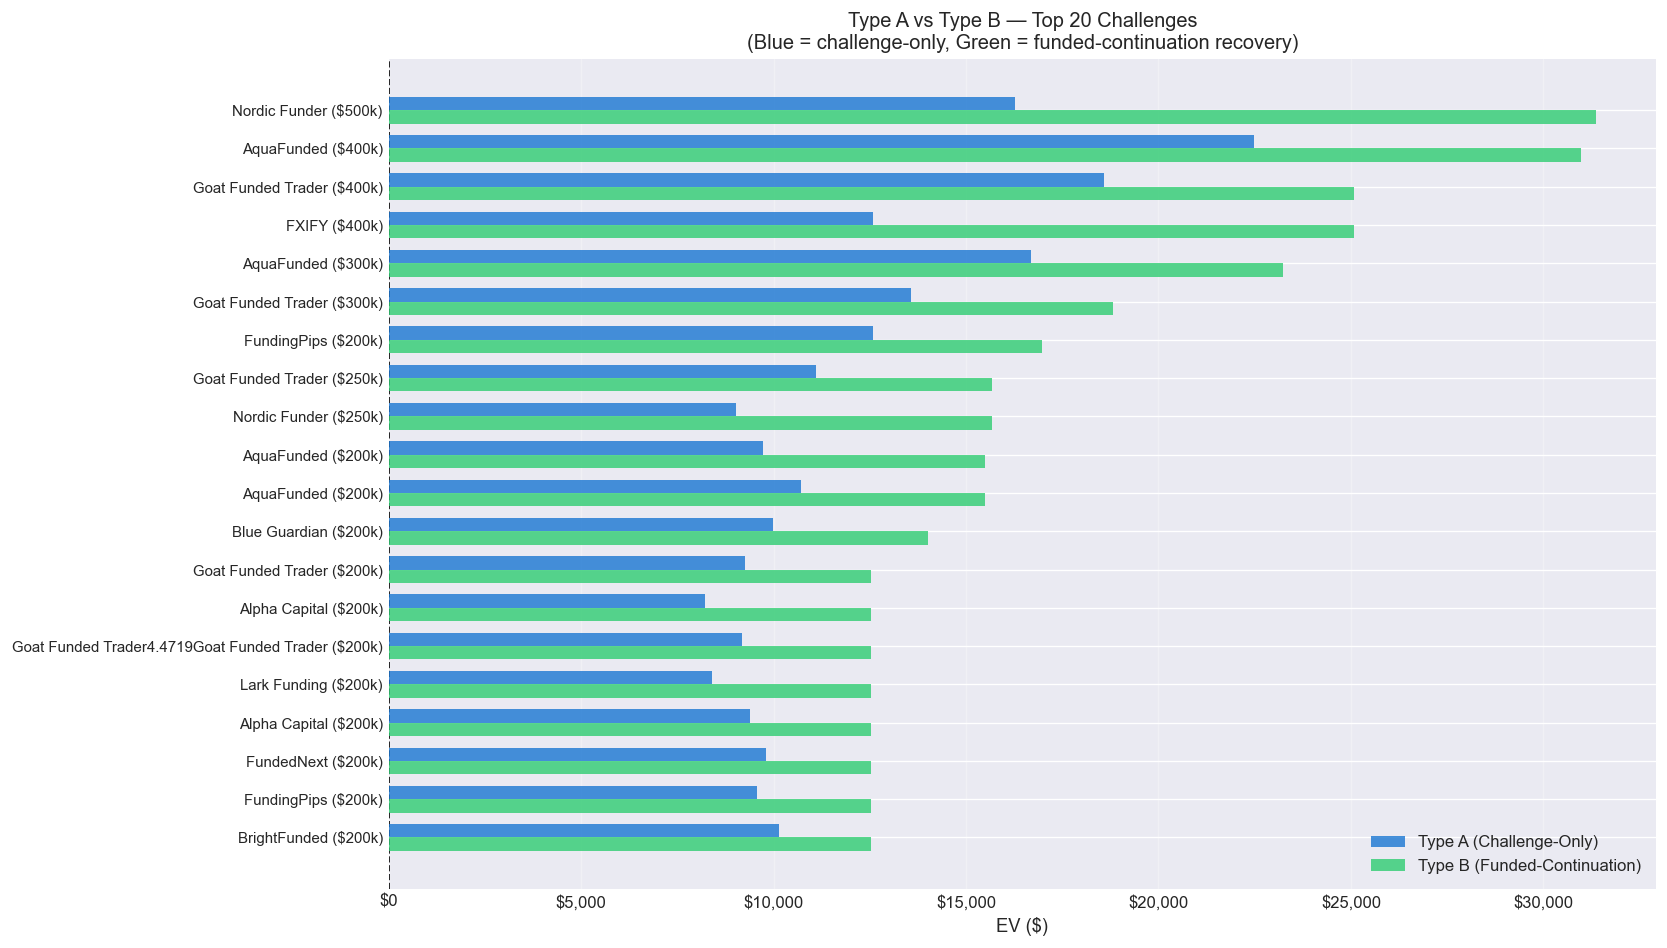

In [5]:
top20 = df_b.nlargest(20, "ev_b").sort_values("ev_b", ascending=True).copy()
top20["label"] = top20.apply(
    lambda r: f"{r['firm']} (${r['account_size']/1000:.0f}k)", axis=1
)

fig, ax = plt.subplots(figsize=(14, 8))
y = np.arange(len(top20))
h = 0.35

ax.barh(y + h/2, top20["type_a_ev"], h, label="Type A (Challenge-Only)",
        color="#1976d2", alpha=0.8, zorder=3)
ax.barh(y - h/2, top20["ev_b"], h, label="Type B (Funded-Continuation)",
        color="#2ecc71", alpha=0.8, zorder=3)

ax.set_yticks(y)
ax.set_yticklabels(top20["label"], fontsize=9)
ax.axvline(x=0, color="black", linewidth=1, linestyle="--")
ax.set_xlabel("EV ($)", fontsize=11)
ax.set_title("Type A vs Type B — Top 20 Challenges\n"
             "(Blue = challenge-only, Green = funded-continuation recovery)", fontsize=12)
ax.legend(fontsize=10, loc="lower right")
ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

## 5 — Funded Phase Walkthrough (Single Challenge)

Detailed cycle-by-cycle view of how the insured stack, withdrawals, and drag evolve.

In [6]:
# Pick the best Type B challenge
best_idx = df_b["ev_b"].idxmax()
best = results_b[best_idx]

print(f"Challenge: {best['firm']} — ${best['account_size']:,}")
print(f"Challenge cost (Type A): ${best['challenge_cost']:,.2f}")
print(f"Type A EV: ${best['type_a_ev']:,.2f}")
print(f"Type B EV: ${best['ev_b']:,.2f}")
print(f"Advantage: ${best['ev_advantage']:+,.2f}")
print()

df_cycles = pd.DataFrame(best["cycles"])
df_cycles.style.format({
    "prob_alive": "{:.1%}",
    "insured_stack": "${:,.2f}",
    "withdrawal": "${:,.2f}",
    "exp_withdrawal": "${:,.2f}",
    "drag": "${:,.2f}",
    "exp_drag": "${:,.2f}",
    "prob_fail": "{:.1%}",
    "exp_recovery": "${:,.2f}",
    "hedge_size_funded": "${:,.0f}",
    "capital_funded": "${:,.0f}",
}).set_caption(f"Type B Cycle Detail — {best['firm']} ${best['account_size']:,}")

Challenge: Nordic Funder — $500,000
Challenge cost (Type A): $15,735.88
Type A EV: $16,264.12
Type B EV: $31,358.88
Advantage: $+15,094.76



,cycle,prob_alive,insured_stack,withdrawal,exp_withdrawal,drag,exp_drag,prob_fail,exp_recovery,hedge_size_funded,capital_funded
0,1,100.0%,"$15,735.88","$16,000.00","$16,000.00","$7,500.00","$7,500.00",20.0%,"$4,647.18","$464,718","$39,501"
1,2,80.0%,"$23,235.88","$16,000.00","$12,800.00","$7,500.00","$6,000.00",16.0%,"$4,917.74","$614,718","$52,251"
2,3,64.0%,"$30,735.88","$16,000.00","$10,240.00","$7,500.00","$4,800.00",12.8%,"$4,894.19","$764,718","$65,001"
3,4,51.2%,"$38,235.88","$16,000.00","$8,192.00","$7,500.00","$3,840.00",10.2%,"$4,683.35","$914,718","$77,751"
4,5,41.0%,"$45,735.88","$16,000.00","$6,553.60","$7,500.00","$3,072.00",8.2%,"$4,361.08","$1,064,718","$90,501"
5,6,32.8%,"$53,235.88","$16,000.00","$5,242.88","$7,500.00","$2,457.60",6.6%,"$3,980.39","$1,214,718","$103,251"


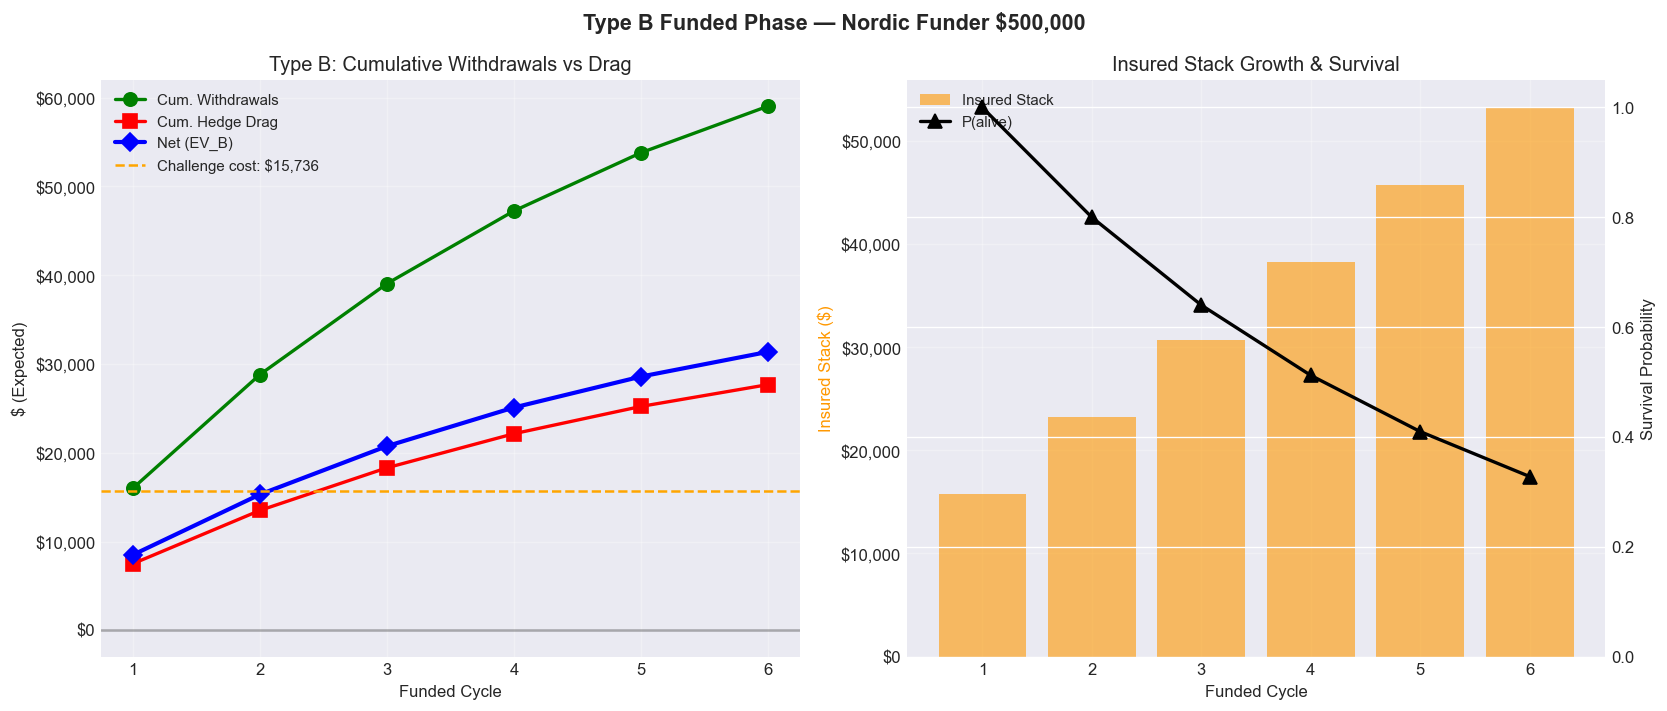

In [7]:
# Visualise the funded phase
cycles = best["cycles"]
cyc_nums = [c["cycle"] for c in cycles]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Left: cumulative withdrawals vs cumulative drag
cum_w = np.cumsum([c["exp_withdrawal"] for c in cycles])
cum_d = np.cumsum([c["exp_drag"] for c in cycles])
cum_net = cum_w - cum_d

ax1.plot(cyc_nums, cum_w, 'g-o', linewidth=2, markersize=8, label="Cum. Withdrawals")
ax1.plot(cyc_nums, cum_d, 'r-s', linewidth=2, markersize=8, label="Cum. Hedge Drag")
ax1.plot(cyc_nums, cum_net, 'b-D', linewidth=2.5, markersize=8, label="Net (EV_B)")
ax1.axhline(y=best["challenge_cost"], color="orange", linestyle="--", linewidth=1.5,
            label=f"Challenge cost: ${best['challenge_cost']:,.0f}")
ax1.axhline(y=0, color="black", linestyle="-", alpha=0.3)

ax1.set_xlabel("Funded Cycle")
ax1.set_ylabel("$ (Expected)")
ax1.set_title("Type B: Cumulative Withdrawals vs Drag")
ax1.legend(fontsize=9)
ax1.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax1.grid(alpha=0.3)

# Right: insured stack growth and survival probability
stacks = [c["insured_stack"] for c in cycles]
probs = [c["prob_alive"] for c in cycles]

ax2_twin = ax2.twinx()
ax2.bar(cyc_nums, stacks, alpha=0.6, color="#ff9800", label="Insured Stack", zorder=3)
ax2_twin.plot(cyc_nums, probs, 'k-^', linewidth=2, markersize=8, label="P(alive)")

ax2.set_xlabel("Funded Cycle")
ax2.set_ylabel("Insured Stack ($)", color="#ff9800")
ax2_twin.set_ylabel("Survival Probability")
ax2.set_title("Insured Stack Growth & Survival")
ax2.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax2_twin.set_ylim(0, 1.05)

lines1, labels1 = ax2.get_legend_handles_labels()
lines2, labels2 = ax2_twin.get_legend_handles_labels()
ax2.legend(lines1 + lines2, labels1 + labels2, fontsize=9)
ax2.grid(alpha=0.3)

plt.suptitle(f"Type B Funded Phase — {best['firm']} ${best['account_size']:,}",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## 6 — Survival Rate Sensitivity

How does the funded account's survival probability affect Type B EV?

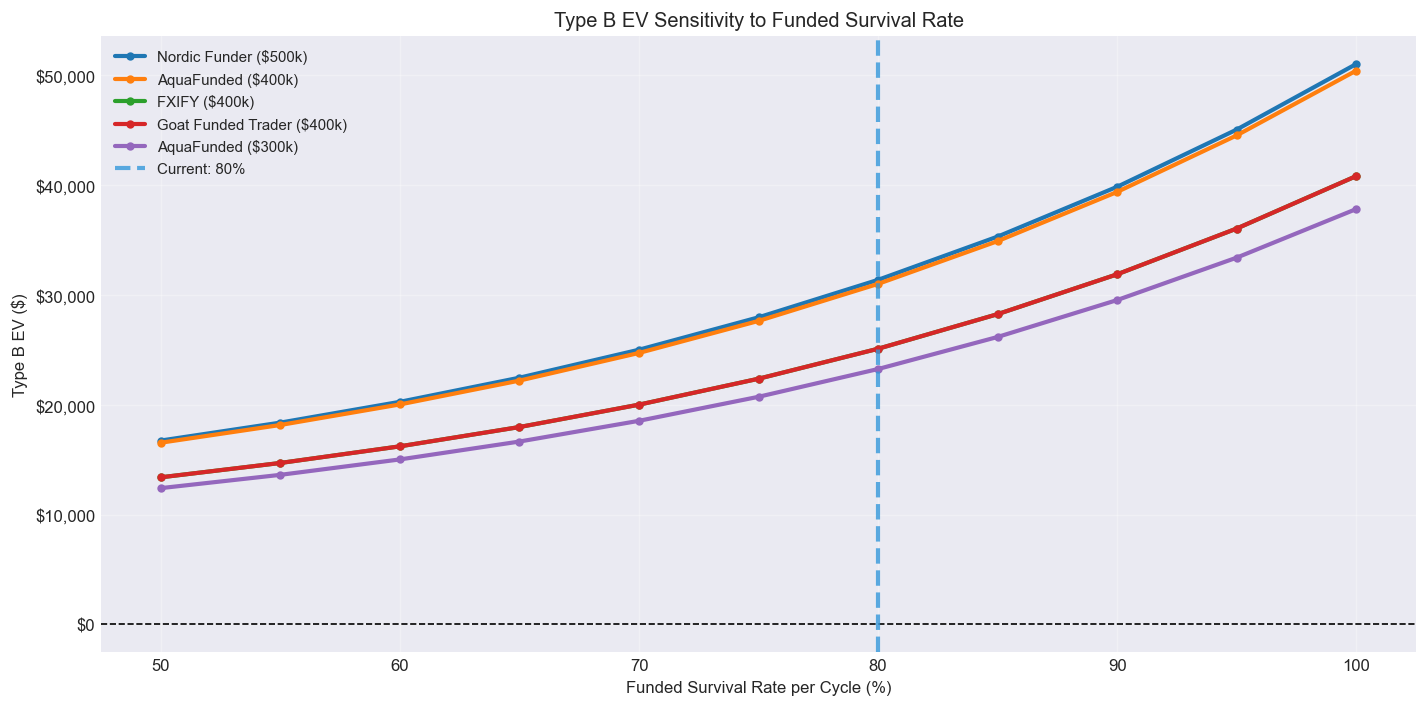

In [8]:
# Pick top 5 challenges
top5_idx = df_b.nlargest(5, "ev_b").index.tolist()
top5_challenges = [challenges[i] for i in top5_idx]

survival_sweep = np.arange(0.50, 1.01, 0.05)

fig, ax = plt.subplots(figsize=(12, 6))
colors = plt.cm.tab10.colors

for i, ch in enumerate(top5_challenges):
    evs = [compute_type_b(ch, survival_rate=sr)["ev_b"] for sr in survival_sweep]
    label = f"{ch['firm']} (${ch['account_size']/1000:.0f}k)"
    ax.plot(survival_sweep * 100, evs, marker='o', markersize=4,
            label=label, linewidth=2.5, color=colors[i % 10])

ax.axhline(y=0, color="black", linewidth=1, linestyle="--")
ax.axvline(x=FUNDED_SURVIVAL_RATE * 100, color="#3498db", linewidth=2.5,
           linestyle="--", alpha=0.8, label=f"Current: {FUNDED_SURVIVAL_RATE*100:.0f}%")

ax.set_xlabel("Funded Survival Rate per Cycle (%)")
ax.set_ylabel("Type B EV ($)")
ax.set_title("Type B EV Sensitivity to Funded Survival Rate")
ax.legend(fontsize=9, loc='upper left')
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 7 — EV Advantage Distribution (Type B − Type A)

How much does continuing to hedge at funded actually add?

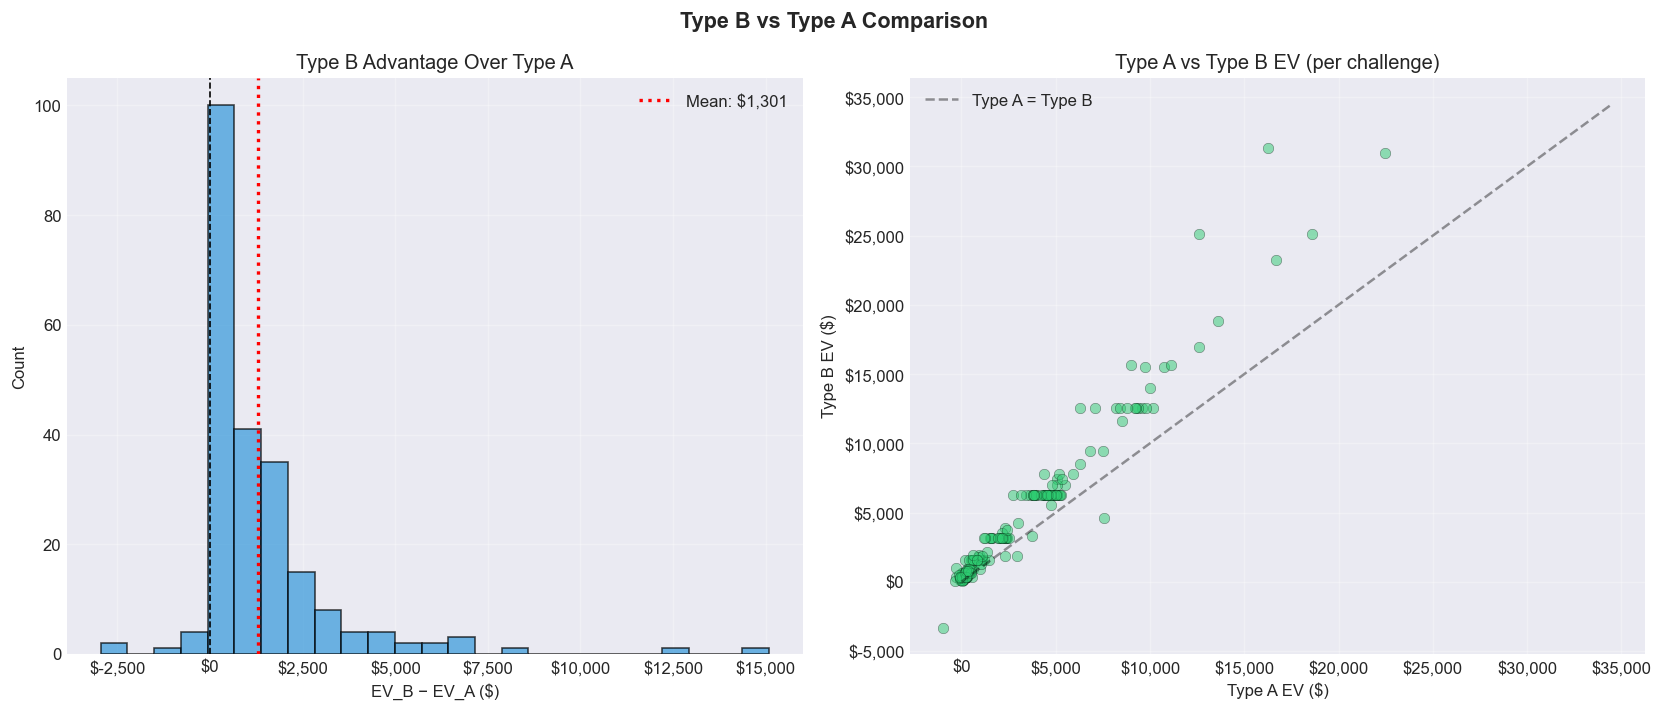


Type B beats Type A in 217/224 challenges
Average advantage: $1,300.98


In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Left: histogram of EV advantage
ax1.hist(df_b["ev_advantage"], bins=25, color="#3498db", alpha=0.7, edgecolor="black")
ax1.axvline(x=0, color="black", linestyle="--", linewidth=1)
ax1.axvline(x=df_b["ev_advantage"].mean(), color="red", linestyle=":", linewidth=2,
            label=f"Mean: ${df_b['ev_advantage'].mean():,.0f}")
ax1.set_xlabel("EV_B − EV_A ($)")
ax1.set_ylabel("Count")
ax1.set_title("Type B Advantage Over Type A")
ax1.legend()
ax1.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax1.grid(alpha=0.3)

# Right: scatter Type A EV vs Type B EV
ax2.scatter(df_b["type_a_ev"], df_b["ev_b"], alpha=0.5, c="#2ecc71",
            edgecolors="black", linewidth=0.3, s=40)
lim = max(df_b["type_a_ev"].max(), df_b["ev_b"].max()) * 1.1
ax2.plot([0, lim], [0, lim], 'k--', alpha=0.4, label="Type A = Type B")
ax2.set_xlabel("Type A EV ($)")
ax2.set_ylabel("Type B EV ($)")
ax2.set_title("Type A vs Type B EV (per challenge)")
ax2.legend()
ax2.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax2.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax2.grid(alpha=0.3)

plt.suptitle("Type B vs Type A Comparison", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

better = (df_b["ev_advantage"] > 0).sum()
print(f"\nType B beats Type A in {better}/{len(df_b)} challenges")
print(f"Average advantage: ${df_b['ev_advantage'].mean():,.2f}")

## 8 — Type B Summary

### What Type B tells you

- Challenge costs are no longer sunk — they're part of the insured base the funded hedge protects.
- EV_B = expected funded withdrawals − expected hedge drag.
- The funded hedge grows the insured stack over time (drag adds to it).
- If the funded account dies, the hedge recovers the full historical stack.

### When to use Type B

- You plan to stay in funded accounts long-term
- You want recovery protection if the funded account fails post-challenge
- You don't want challenge costs to be 100% sunk

### Limitations

- More complex operations — the hedge continues at funded stage
- Hedge drag is a real ongoing cost
- Capital requirement is higher (hedge runs longer)
- Failure only **recovers** costs — it doesn't produce surplus profit

→ For surplus on failure, see **Type C** notebook.